In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2

import optuna
from optuna import Trial
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, f1_score, recall_score, precision_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import os
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from typing import List

from functools import partial
from tqdm import tqdm

c:\Users\Kacper\PycharmProjects\Skin-lesion-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Width and height that the image is resized to
TRAIN_W, TRAIN_H = 100, 100
N_FOLD_SPLITS = 4
BATCH_SIZE = 1024
EPOCHS = 20

SEED = 0
NUM_WORKERS = 0

device = "cuda" if torch.cuda.is_available() else "cpu"

activation_functions = {
	"relu": nn.ReLU,
	"sigmoid": nn.Sigmoid,
	"tanh": nn.Tanh
}


# Dataset

In [3]:
class SkinDataset(Dataset):
	def __init__(self, images_dir: str, image_names: str, labels: str, transforms=None) -> None:
		super().__init__()
		self.image_paths = [os.path.join(images_dir, f"{image_name}.jpg") for image_name in image_names]

		self.label_dict = dict(zip(self.image_paths, labels))

		self.transforms = transforms

		self.ram_resizer = v2.Resize((TRAIN_W, TRAIN_H))
		self.preloaded_images = {}

		for img_path in tqdm(self.image_paths, leave=False):
			img = Image.open(img_path).convert("RGB")
			img = self.ram_resizer(img)
			self.preloaded_images[img_path] = img

	def __len__(self):
		return len(self.image_paths)
	
	def __getitem__(self, idx):
		img_path = self.image_paths[idx]
		label = self.label_dict[img_path]
		#img = Image.open(img_path).convert("RGB")
		img = self.preloaded_images[img_path]
		label = torch.tensor(label, dtype=torch.long)

		if self.transforms:
			img = self.transforms(img)
		
		return img, label

# Model class

In [4]:
class Model(nn.Module):
	def __init__(self,  n_inputs: int, layers: List, n_outputs: int, activation=nn.ReLU) -> None:
		super().__init__()
		while 0 in layers:
			layers.remove(0)

		model_layers = []

		if len(layers) == 0:
			# Direct connection from inputs to outputs
			model_layers.append(nn.Sequential(
				nn.Linear(n_inputs, n_outputs)
				))
		else:
			# Input layer
			model_layers.append(nn.Sequential(
				nn.Linear(n_inputs, layers[0]),
				activation()
			))

			# Hidden layers
			for i in range(1, len(layers)):
				model_layers.append(nn.Sequential(
					nn.Linear(layers[i-1], layers[i]),
					activation()
				))

			# Output layer
			model_layers.append(nn.Sequential(
				nn.Linear(layers[-1], n_outputs)
			))

		self.fc = nn.Sequential(*model_layers)

	def forward(self, x):
		return self.fc(x)

### Load dataset

In [ ]:
train_images_dir = "data/HAM10000_images_merged"
train_labels_path = "data/HAM10000_metadata.csv"

test_images_dir = "data/ISIC2018_Task3_Test_Images/ISIC2018_Task3_Test_Images"
test_labels_path = "data/ISIC2018_Task3_Test_GroundTruth.csv"

train_preprocessing = v2.Compose([
	#v2.Resize((TRAIN_H, TRAIN_W)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=15),
	v2.ToImage(),
	v2.ToDtype(torch.float32, scale=True),
	v2.Normalize(mean=[0, 0, 0], std=[1, 1, 1]),
	v2.Lambda(lambda x: torch.flatten(x))
])

test_preprocessing = v2.Compose([
	#v2.Resize((TRAIN_H, TRAIN_W)),
	v2.ToImage(),
	v2.ToDtype(torch.float32, scale=True),
	v2.Normalize(mean=[0, 0, 0], std=[1, 1, 1]),
	v2.Lambda(lambda x: torch.flatten(x))
])

In [ ]:
def map_labels(x):
	if x not in ["nv", "mel"]:
		return "other"
	return x

def preprocess_labels(df):
	labels = df["dx"].map(map_labels)
	return labels.map({"nv": 0, "mel": 1, "other": 2})

train_image_paths = [img_path for img_path in glob(os.path.join(train_images_dir, "*"))]
train_df = pd.read_csv(train_labels_path)
train_df = train_df[train_df.image_id.isin([os.path.splitext(os.path.basename(img_path))[0] for img_path in train_image_paths])]
train_df["label"] = preprocess_labels(train_df)

test_image_paths = [img_path for img_path in glob(os.path.join(test_images_dir, "*"))]
test_df = pd.read_csv(test_labels_path)
test_df = test_df[test_df.image_id.isin([os.path.splitext(os.path.basename(img_path))[0] for img_path in test_image_paths])]
test_df["label"] = preprocess_labels(test_df)


train_images, val_images, train_labels, val_labels = train_test_split(train_df.image_id, train_df.label, test_size=0.2, random_state=SEED, stratify=train_df.label)

train_dataset = SkinDataset(train_images_dir, train_images, train_labels, transforms = train_preprocessing)
val_dataset = SkinDataset(train_images_dir, val_images, val_labels, transforms = test_preprocessing)
test_dataset = SkinDataset(test_images_dir, test_df.image_id, test_df.label, transforms = test_preprocessing)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

unique_classes = np.unique(train_df["label"])
balanced_weights = compute_class_weight(class_weight="balanced", classes=unique_classes, y=train_df["label"])
class_weights = torch.tensor(balanced_weights, dtype=torch.float32).to(device)


KeyboardInterrupt: 

In [ ]:
n_inputs = TRAIN_H*TRAIN_W*3
n_outputs = len(np.unique(list(train_dataset.label_dict.values())))

print(f"Number of inputs: {n_inputs}")
print(f"Number of outputs: {n_outputs}")

Number of inputs: 30000
Number of outputs: 3


In [ ]:
def calculate_metrics(y_true, y_pred):
	argmax_preds = np.argmax(y_pred, axis=1)
	y_true_bin = label_binarize(y_true, classes=[i for i in range(n_outputs)])

	f1 = f1_score(y_true, argmax_preds, average="macro")
	recall = recall_score(y_true, argmax_preds, average="macro")
	precision = precision_score(y_true, argmax_preds, average="macro", zero_division=0)
	accuracy = accuracy_score(y_true, argmax_preds)    
	auprc = average_precision_score(y_true_bin, y_pred)
	return auprc, f1, recall, precision, accuracy

In [ ]:
torch.no_grad()
def get_val_preds(model, dataloader, criterion):
	model.eval()

	preds = []
	gts = []
	total_loss = 0.0
	for images, labels in tqdm(dataloader):
		images = images.to(device)
		labels = labels.to(device)

		outputs = model(images)
		loss = criterion(outputs, labels)

		preds.extend(F.softmax(outputs, dim=-1).tolist())
		gts.extend(labels.tolist())

		total_loss += loss.item() * images.shape[0]

	return total_loss / len(dataloader.dataset), preds, gts

In [ ]:
def train_one_epoch(model, dataloader, optimizer, criterion):
	model.train()

	preds = []
	gts = []
	total_loss = 0.0
	for images, labels in tqdm(dataloader):
		images = images.to(device)
		labels = labels.to(device)

		optimizer.zero_grad()
		outputs = model(images)
		loss = criterion(outputs, labels)
		loss.backward()
		optimizer.step()

		preds.extend(F.softmax(outputs, dim=-1).tolist())
		gts.extend(labels.tolist())

		total_loss += loss.item() * images.shape[0]

	return total_loss / len(dataloader.dataset), preds, gts

# K fold cross validation

In [ ]:
# def k_fold_val(model_args, dataset, lr):
# 	kfold = StratifiedKFold(n_splits=N_FOLD_SPLITS, shuffle=True)
# 	folds = kfold.split(dataset, y=list(dataset.label_dict.values()))

# 	criterion = nn.CrossEntropyLoss()
# 	train_preprocessing = v2.Compose([
# 		v2.Resize((TRAIN_H, TRAIN_W)),
# 		v2.ToImage(),
# 		v2.ToDtype(torch.float32, scale=True),
# 		v2.Normalize(mean=[0, 0, 0], std=[1, 1, 1]),
# 		v2.Lambda(lambda x: torch.flatten(x))
# 	])

# 	test_preprocessing = v2.Compose([
# 		v2.Resize((TRAIN_H, TRAIN_W)),
# 		v2.ToImage(),
# 		v2.ToDtype(torch.float32, scale=True),
# 		v2.Normalize(mean=[0, 0, 0], std=[1, 1, 1]),
# 		v2.Lambda(lambda x: torch.flatten(x))
# 	])

# 	mean_val_auprc = 0.0
# 	for train_ids, val_ids in folds:
# 		model = Model(*model_args).to(device)
# 		optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# 		train_subset = Subset(dataset, indices=train_ids)
# 		val_subset = Subset(dataset, indices=val_ids)

# 		train_dataset = DatasetWithTransforms(train_subset, train_preprocessing)
# 		val_dataset = DatasetWithTransforms(val_subset, test_preprocessing)

# 		train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
# 		val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# 		best_auprc = 0.0
		
# 		for epoch in range(EPOCHS):
# 			train_loss, train_preds, train_gts = train_one_epoch(model, train_dataloader, optimizer, criterion)
# 			train_auprc, train_f1, train_recall, train_precision, train_accuracy = calculate_metrics(train_gts, train_preds)

# 			val_loss, val_preds, val_gts = get_val_preds(model, val_dataloader, criterion)
# 			val_auprc, val_f1, val_recall, val_precision, val_accuracy = calculate_metrics(val_gts, val_preds)

# 			print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}, Train AUPRC: {train_auprc:.4f}, Val Loss: {val_loss:.4f}, Val AUPRC: {val_auprc:.4f}")

# 			if val_auprc > best_auprc:
# 				best_auprc = val_auprc

# 		mean_val_auprc += best_auprc
	
# 	return mean_val_auprc / N_FOLD_SPLITS
		

In [ ]:
def train(model_args, train_dataloader, val_dataloader, lr, trial=None):
	model = Model(*model_args).to(device)
	optimizer = torch.optim.Adam(model.parameters(), lr=lr)
	criterion = nn.CrossEntropyLoss(weight=class_weights)

	best_auprc = 0.0
	
	for epoch in range(EPOCHS):
		train_loss, train_preds, train_gts = train_one_epoch(model, train_dataloader, optimizer, criterion)
		train_auprc, train_f1, train_recall, train_precision, train_accuracy = calculate_metrics(train_gts, train_preds)

		val_loss, val_preds, val_gts = get_val_preds(model, val_dataloader, criterion)
		val_auprc, val_f1, val_recall, val_precision, val_accuracy = calculate_metrics(val_gts, val_preds)

		print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}, Train AUPRC: {train_auprc:.4f}, Val Loss: {val_loss:.4f}, Val AUPRC: {val_auprc:.4f}")

		if val_auprc > best_auprc:
			best_auprc = val_auprc
		
		if trial is not None:
			trial.report(val_auprc, epoch)

			if trial.should_prune():
				print(f"Trial pruned at epoch {epoch+1} with AUPRC: {val_auprc:.4f}")
				raise optuna.exceptions.TrialPruned()

	return best_auprc

In [ ]:
def evaluate(model, dataloader, device, dataset_name="Test Set"):
    model.eval()
    test_preds = []
    test_labels = []
    test_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"Evaluating model on {dataset_name}", leave=False):
            images.to(device)
            labels.to(device)

            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            test_preds.extend(preds.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())
            test_probs.extend(probs.cpu().numpy())
    
    test_labels = np.array(test_labels)
    test_preds = np.array(test_preds)
    test_probs = np.array(test_probs)

    auprc, f1, recall, precision, accuracy = calculate_metrics(test_labels, test_preds)

    print(f"{dataset_name} results: \n")
    print("Evaluation metrics:\n")

    print(f"AUPRC: {auprc:.4f}")
    print(f"Macro F1: {f1:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Accuracy: {accuracy:.4f}")

    class_names = ["nv (Benign)", "mel (Melanoma)", "other"]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Model Performance Dashboard: {dataset_name}", fontsize=16, fontweight='bold')

    cm = confusion_matrix(test_labels, test_preds)
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    display.plot(cmap = plt.cm.Blues, ax= axes[0], colorbar=False)
    axes[0].set_title("Confusion Matrix", fontsize=14)
    
    report = classification_report(test_labels, test_preds,target_names=class_names, output_dict=True)

    metrics_df = pd.DataFrame({
        'Metric': ['Precision', 'Recall', 'F1-Score'] *3,
        'Score': [
            report[class_names[0]]['precision'], report[class_names[0]]['recall'], report[class_names[0]]['f1-score'],
            report[class_names[1]]['precision'], report[class_names[1]]['recall'], report[class_names[1]]['f1-score'],
            report[class_names[2]]['precision'], report[class_names[2]]['recall'], report[class_names[2]]['f1-score']
        ],
        'Class': [class_names[0]]*3 + [class_names[1]]*3  + [class_names[2]]*3
    })

    sns.barplot(data=metrics_df, x='Class', y='Score', hue='Metric', ax=axes[1], palette='viridis')
    axes[1].set_title("Precision, Recall, F1-Score Per Class breakdown", fontsize=14)
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()


In [ ]:
def prepare_and_evaluate_hidden_test_dataset(model, images_dir, labels_path, device):
    hidden_image_paths = [img_path for img_path in glob(os.path.join(images_dir, "*"))]
    hidden_df = pd.read_csv(labels_path)

    hidden_df = hidden_df[hidden_df.image_id.isin([os.path.splitext(os.path.basename(img_path))[0] for img_path in hidden_image_paths])]
    hidden_df["label"] = preprocess_labels(hidden_df)
    
    hidden_dataset = SkinDataset(
        images_dir=images_dir,
        image_names=hidden_df.image_id,
        labels=hidden_df.label,
        transforms=test_preprocessing
    )

    hidden_dataloader = DataLoader(hidden_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    evaluate(model, hidden_dataloader, device, dataset_name="Hidden Evaluation Set")
    

    

In [ ]:
def objective(trial: Trial, train_dataloader: DataLoader, val_dataloader: DataLoader):
	layers = []
	layers.append(trial.suggest_categorical("layer1_neurons", [512, 1024, 2048]))
	layers.append(trial.suggest_categorical("layer2_neurons", [128, 256, 512]))
	layers.append(trial.suggest_categorical("layer3_neurons", [0, 32, 64]))
	# layers.append(trial.suggest_categorical("layer4_neurons", [0, 16, 32, 64, 128, 256, 512]))
	# layers.append(trial.suggest_categorical("layer5_neurons", [0, 16, 32, 64, 128, 256, 512]))
	lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
	activation = trial.suggest_categorical("activation", ["relu", "sigmoid", "tanh"])
	activation = activation_functions[activation]

	print(f"Testing model with layers {layers}, learning rate {lr}, and activation {activation}")
	
	model_args = [n_inputs, layers, n_outputs, activation]

	mean_auprc = train(model_args, train_dataloader, val_dataloader, lr, trial=trial)

	return mean_auprc


In [ ]:

study = optuna.create_study(
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=5),
    direction="maximize"
)

objective_with_args = partial(objective, train_dataloader=train_dataloader, val_dataloader=val_dataloader)

study.optimize(objective_with_args, n_trials=20)


[I 2026-06-05 11:20:22,151] A new study created in memory with name: no-name-090c9f6f-5781-4b3a-b4d4-dfb2adda8ee5


Testing model with layers [512, 512, 256], learning rate 0.001, and activation <class 'torch.nn.modules.activation.Sigmoid'>


100%|██████████| 2/2 [00:01<00:00,  1.34it/s]


Epoch 1/20 - Train Loss: 0.8996, Train AUPRC: 0.3391, Val Loss: 0.8588, Val AUPRC: 0.3326


100%|██████████| 2/2 [00:01<00:00,  1.32it/s]


...

Epoch 18/20 - Train Loss: 0.6335, Train AUPRC: 0.5988, Val Loss: 0.6376, Val AUPRC: 0.6008


100%|██████████| 2/2 [00:02<00:00,  1.47s/it]


Epoch 19/20 - Train Loss: 0.6359, Train AUPRC: 0.5969, Val Loss: 0.6386, Val AUPRC: 0.6014


100%|██████████| 2/2 [00:02<00:00,  1.44s/it]
[I 2026-06-05 12:34:20,803] Trial 19 finished with value: 0.6023127786990022 and parameters: {'layer1_neurons': 4096, 'layer2_neurons': 64, 'layer3_neurons': 512, 'lr': 0.0001, 'activation': 'relu'}. Best is trial 19 with value: 0.6023127786990022.


Epoch 20/20 - Train Loss: 0.6361, Train AUPRC: 0.5982, Val Loss: 0.6334, Val AUPRC: 0.6023


In [ ]:
study.trials_dataframe().to_csv("optuna_trials.csv", index=False)

In [ ]:
print(f"Best params: {study.best_params}")
print(f"Best AUPRC: {study.best_value:.4f}")

Best params: {'layer1_neurons': 4096, 'layer2_neurons': 64, 'layer3_neurons': 512, 'lr': 0.0001, 'activation': 'relu'}
Best AUPRC: 0.6023


# Final train with optimal hyperparameters

In [ ]:
model_args = [n_inputs, [study.best_params[f"layer{i}_neurons"] for i in range(1, 3)], n_outputs, activation_functions[study.best_params["activation"]]]
best_model = Model(*model_args).to(device)
optimizer = torch.optim.Adam(best_model.parameters(), lr=study.best_params["lr"])
criterion = nn.CrossEntropyLoss(weight=class_weights)

train_losses = []
val_losses = []
train_auprcs = []
val_auprcs = []

best_auprc = 0.0
best_val_loss = float("inf")

patience_counter = 0
patience = 30
for epoch in range(1000):
	train_loss, train_preds, train_gts = train_one_epoch(best_model, train_dataloader, optimizer, criterion)
	train_auprc, train_f1, train_recall, train_precision, train_accuracy = calculate_metrics(train_gts, train_preds)

	val_loss, val_preds, val_gts = get_val_preds(best_model, val_dataloader, criterion)
	val_auprc, val_f1, val_recall, val_precision, val_accuracy = calculate_metrics(val_gts, val_preds)

	train_losses.append(train_loss)
	val_losses.append(val_loss)
	train_auprcs.append(train_auprc)
	val_auprcs.append(val_auprc)

	print(f"Epoch {epoch+1}/200 - Train Loss: {train_loss:.4f}, Train AUPRC: {train_auprc:.4f}, Val Loss: {val_loss:.4f}, Val AUPRC: {val_auprc:.4f}")

	if val_auprc > best_auprc:
		best_auprc = val_auprc
		torch.save(best_model.state_dict(), "best_model.pth")
	torch.save(best_model.state_dict(), "last_model.pth")

	if val_loss < best_val_loss:
		best_val_loss = val_loss
		patience_counter = 0
	else:
		patience_counter += 1

	if patience_counter >= patience:
		print("Early stopping triggered")
		break

100%|██████████| 2/2 [00:02<00:00,  1.45s/it]


Epoch 1/200 - Train Loss: 1.0330, Train AUPRC: 0.3428, Val Loss: 0.8165, Val AUPRC: 0.4688


100%|██████████| 2/2 [00:02<00:00,  1.43s/it]


Epoch 2/200 - Train Loss: 0.8162, Train AUPRC: 0.4199, Val Loss: 0.7837, Val AUPRC: 0.5037


100%|██████████| 2/2 [00:02<00:00,  1.43s/it]


...

Epoch 316/200 - Train Loss: 0.4748, Train AUPRC: 0.7636, Val Loss: 0.5695, Val AUPRC: 0.6688


100%|██████████| 2/2 [00:02<00:00,  1.42s/it]


Epoch 317/200 - Train Loss: 0.4734, Train AUPRC: 0.7652, Val Loss: 0.5634, Val AUPRC: 0.6672


100%|██████████| 2/2 [00:02<00:00,  1.34s/it]


Epoch 318/200 - Train Loss: 0.4719, Train AUPRC: 0.7643, Val Loss: 0.5904, Val AUPRC: 0.6644
Early stopping triggered


In [ ]:
plt.style.use("default")

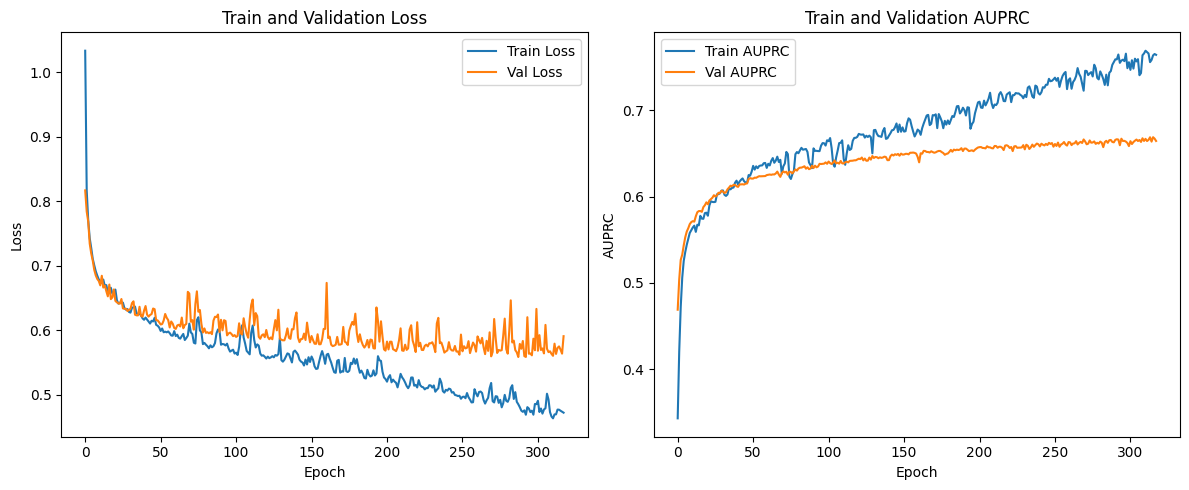

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train and Validation Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_auprcs, label="Train AUPRC")
plt.plot(val_auprcs, label="Val AUPRC")
plt.xlabel("Epoch")
plt.ylabel("AUPRC")
plt.title("Train and Validation AUPRC")
plt.legend()
plt.tight_layout()
plt.show()

# Test set evaluation

In [ ]:
evaluate(model=best_model, dataloader=test_dataloader, device=device, dataset_name="Known Test Set")

AttributeError: 'collections.OrderedDict' object has no attribute 'eval'

# Hidden test set evaluation cell

In [ ]:
hidden_images_dir = "path/to/images"  #Change to correct path to evaluate on hidden dataset
hidden_labels_path = "path/to/labels_csv" #Change to correct path to evaluate on hidden dataset

prepare_and_evaluate_hidden_test_dataset(model=best_model, images_dir=hidden_images_dir, labels_path=hidden_labels_path, device=device)

